In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2025-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Univariate Classification — Logistic Regression, LDA, QDA (ISLR Ch. 4)
=======================================================================

Description:
    Demonstrates univariate binary classification using three methods:
      1. Logistic Regression   (sklearn.LogisticRegression)
      2. Linear Discriminant Analysis — LDA  (sklearn.LinearDiscriminantAnalysis)
      3. Quadratic Discriminant Analysis — QDA (sklearn.QuadraticDiscriminantAnalysis)

    Data is synthetically generated: two overlapping Normal distributions
    representing two classes (A=0, B=1), with a single numeric predictor X.

    For each classifier:
      - Fit on train set
      - Predict on test set
      - Confusion matrix
      - Custom prediction metrics (OBS, ACC, TPR, TNR, PPV, NPV, FDR, FPR,
        TP, TN, FP, FN, P, N)
      - ROC curve with AUC

    A reusable PredictionMetrics class mirrors the R prediction.metrics()
    and print.the.metrics() functions from the original Harvard class code.

    R equivalent: univar_logistic_reg_LDA_QDA_classification.Rmd
    R libraries:  stats (glm), MASS (lda, qda), caret, pROC, ggplot2
    Python libs:  numpy, pandas, matplotlib, seaborn, sklearn, scipy

Dataset:
    Simulated — two Normal distributions (N=1000 each)
    Class A (Y=0): X ~ N(0, 1)
    Class B (Y=1): X ~ N(mu=2, sd=2)
    Single predictor: X (continuous, numeric)
    Response: Y (binary: 0=A, 1=B)

Revision History:
    2025-01-01  Original R development (Harvard Elements of Statistical Learning, 2021)
                - R script: univar_logistic_reg_LDA_QDA_classification.Rmd
                - Based on functions from Dr. Sivachenko and Dr. Farutin

    2026-04-03  Converted to Python / Jupyter Notebook
                - glm(family=binomial) → sklearn.LogisticRegression
                - MASS::lda() → sklearn.LinearDiscriminantAnalysis
                - MASS::qda() → sklearn.QuadraticDiscriminantAnalysis
                - pROC::roc + plot.roc → sklearn.metrics.roc_curve + matplotlib
                - caret::confusionMatrix → sklearn.metrics.confusion_matrix
                - prediction.metrics() R function → PredictionMetrics Python class
                - Harvard color palette (crimson, royalblue) preserved as hex constants
"""

'\nCreated on 2025-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nUnivariate Classification — Logistic Regression, LDA, QDA (ISLR Ch. 4)\n=======================================================================\n\nDescription:\n    Demonstrates univariate binary classification using three methods:\n      1. Logistic Regression   (sklearn.LogisticRegression)\n      2. Linear Discriminant Analysis — LDA  (sklearn.LinearDiscriminantAnalysis)\n      3. Quadratic Discriminant Analysis — QDA (sklearn.QuadraticDiscriminantAnalysis)\n\n    Data is synthetically generated: two overlapping Normal distributions\n    representing two classes (A=0, B=1), with a single numeric predictor X.\n\n    For each classifier:\n      - Fit on train set\n      - Predict on test set

# Univariate Classification — Logistic Regression, LDA, QDA (ISLR Ch. 4)

## Overview

This notebook demonstrates univariate binary classification using three methods
covered in ISLR Chapter 4:

1. **Logistic Regression** — Generalized Linear Model with binomial family
2. **Linear Discriminant Analysis (LDA)** — assumes equal covariance across classes
3. **Quadratic Discriminant Analysis (QDA)** — allows different covariance per class

Data is **synthetically generated**: two overlapping Normal distributions representing
two classes (A=0, B=1), connected through a single continuous numeric predictor X.

For each classifier: fit → predict → confusion matrix → custom metrics → ROC/AUC.

A reusable `PredictionMetrics` class mirrors the custom R functions
(`prediction.metrics`, `print.the.metrics`) originally developed in Harvard's
Elements of Statistical Learning class (2021).

**R equivalent:** `univar_logistic_reg_LDA_QDA_classification.Rmd`

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Classification models — mirrors R: stats::glm, MASS::lda, MASS::qda
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)

# Model evaluation — mirrors R: caret::confusionMatrix, pROC::roc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# crimson='#A51C30', royalblue='#002366', slate='#8996A0'
# ivy='#52854C', saffron='#D16103', indigo='#293352', shade='#BAC5C6'
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


## Custom Functions

### PredictionMetrics Class

Mirrors the R functions `prediction.metrics()` and `print.the.metrics()` originally
developed for Harvard's Elements of Statistical Learning class (2021) by
Dr. Sivachenko and Dr. Farutin, expanded by Oscar Trevizo.

Computes and reports the full set of binary classification metrics:

| Metric | Description |
|--------|-------------|
| OBS | Total observations |
| ACC | Accuracy |
| TPR | True Positive Rate (Sensitivity, Recall) |
| TNR | True Negative Rate (Specificity) |
| PPV | Positive Predictive Value (Precision) |
| NPV | Negative Predictive Value |
| FDR | False Discovery Rate |
| FPR | False Positive Rate |
| TP, TN, FP, FN | Confusion matrix counts |
| P, N | Total positives and negatives in truth |

In [3]:
class PredictionMetrics:
    """
    Binary classification prediction metrics.

    Mirrors R functions prediction.metrics() and print.the.metrics()
    from Harvard Elements of Statistical Learning class (2021).
    Original R code by Dr. Sivachenko and Dr. Farutin; expanded by Oscar Trevizo.

    Parameters
    ----------
    truth : array-like of int (0 or 1)
        Ground truth binary labels.
    predicted : array-like of int (0 or 1)
        Predicted binary labels.

    Attributes
    ----------
    OBS : int    — number of observations
    ACC : float  — accuracy
    TPR : float  — true positive rate (sensitivity)
    TNR : float  — true negative rate (specificity)
    PPV : float  — precision (positive predictive value)
    NPV : float  — negative predictive value
    FDR : float  — false discovery rate
    FPR : float  — false positive rate
    TP, TN, FP, FN : int — confusion matrix counts
    P, N : int   — total positives and negatives in truth
    """

    def __init__(self, truth, predicted):
        truth     = np.array(truth)
        predicted = np.array(predicted)

        if len(truth) != len(predicted):
            raise ValueError('truth and predicted must be the same length!')

        # Remove NaN entries — mirrors R: bKeep = !is.na(truth) & !is.na(predicted)
        mask      = ~(np.isnan(truth.astype(float)) | np.isnan(predicted.astype(float)))
        truth     = truth[mask]
        predicted = predicted[mask]

        # Only 0 and 1 allowed — mirrors R check
        if not np.all(np.isin(truth, [0, 1])) or not np.all(np.isin(predicted, [0, 1])):
            raise ValueError('Only zeroes and ones are allowed!')

        # Confusion matrix counts
        self.TP = int(np.sum((truth == 1) & (predicted == 1)))
        self.TN = int(np.sum((truth == 0) & (predicted == 0)))
        self.FP = int(np.sum((truth == 0) & (predicted == 1)))
        self.FN = int(np.sum((truth == 1) & (predicted == 0)))

        self.P   = self.TP + self.FN   # total positives in truth
        self.N   = self.FP + self.TN   # total negatives in truth
        self.OBS = len(truth)

        self.ACC = np.sum(truth == predicted) / len(truth)
        self.TPR = self.TP / self.P                        if self.P  > 0 else np.nan
        self.TNR = self.TN / self.N                        if self.N  > 0 else np.nan
        self.PPV = self.TP / (self.TP + self.FP)           if (self.TP + self.FP) > 0 else np.nan
        self.NPV = self.TN / (self.TN + self.FN)           if (self.TN + self.FN) > 0 else np.nan
        self.FDR = self.FP / (self.TP + self.FP)           if (self.TP + self.FP) > 0 else np.nan
        self.FPR = self.FP / self.N                        if self.N  > 0 else np.nan

    def print_metrics(self):
        """Print all metrics — mirrors R: print.the.metrics(metrics)"""
        print(f' OBS = {self.OBS:6d}   ..................number of observations')
        print(f' ACC = {self.ACC:8.4f} ..................Accuracy')
        print(f' TPR = {self.TPR:8.4f} ..................True Positive Rate (Sensitivity)')
        print(f' TNR = {self.TNR:8.4f} ..................True Negative Rate (Specificity)')
        print(f' PPV = {self.PPV:8.4f} ..................Positive Predictive Value (Precision)')
        print(f' NPV = {self.NPV:8.4f} ..................Negative Predictive Value')
        print(f' FDR = {self.FDR:8.4f} ..................False Discovery Rate')
        print(f' FPR = {self.FPR:8.4f} ..................False Positive Rate')
        print(f' TP  = {self.TP:6d}   ..................True Positives')
        print(f' TN  = {self.TN:6d}   ..................True Negatives')
        print(f' FP  = {self.FP:6d}   ..................False Positives')
        print(f' FN  = {self.FN:6d}   ..................False Negatives')
        print(f' P   = {self.P:6d}   ..................Positives (truth)')
        print(f' N   = {self.N:6d}   ..................Negatives (truth)')

    def to_dict(self):
        """Return metrics as a dictionary for tabular comparison."""
        return dict(OBS=self.OBS, ACC=self.ACC, TPR=self.TPR, TNR=self.TNR,
                    PPV=self.PPV, NPV=self.NPV, FDR=self.FDR, FPR=self.FPR,
                    TP=self.TP, TN=self.TN, FP=self.FP, FN=self.FN,
                    P=self.P, N=self.N)


print('PredictionMetrics class defined.')

PredictionMetrics class defined.


In [4]:
def plot_roc(fpr, tpr, roc_auc, title='ROC Curve', color=ROYALBLUE):
    """
    Plot ROC curve with AUC.
    Mirrors R: pROC::plot.roc() with print.auc=TRUE, auc.polygon=TRUE.

    Parameters
    ----------
    fpr     : array — false positive rates (from sklearn.metrics.roc_curve)
    tpr     : array — true positive rates
    roc_auc : float — area under the ROC curve
    title   : str
    color   : str   — line color (default: Harvard royalblue)
    """
    fig, ax = plt.subplots(figsize=(6, 5))

    # ROC curve
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'AUC = {roc_auc * 100:.2f}%')

    # Fill under curve — mirrors auc.polygon=TRUE, auc.polygon.col='lightblue'
    ax.fill_between(fpr, tpr, alpha=0.15, color='lightblue')

    # Diagonal reference line (random classifier)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

    # Grid — mirrors grid=c(0.1, 0.2)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, which='both', linestyle='--', linewidth=0.5,
            color='lightgrey')

    ax.set_xlabel('False Positive Rate (1 - Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


print('plot_roc() helper defined.')

plot_roc() helper defined.


---

## Simulate the Data

Mirrors R:
```r
set.seed(11)
N = 1000; mu = 2
x <- c(rnorm(N), rnorm(N, mean=mu, sd=2))
y <- rep(c('A','B'), each=N)
df <- data.frame(Y=ifelse(y=='A', 0, 1), X=x)
```

Two overlapping Normal distributions:
- **Class A (Y=0):** X ~ N(0, 1) — 1000 observations
- **Class B (Y=1):** X ~ N(μ=2, σ=2) — 1000 observations

The overlap between distributions makes this a realistic (non-trivial) classification problem.
Adjusting `mu` or `sd` changes the difficulty.

In [5]:
# Simulate data — mirrors R: set.seed(11)
rng = np.random.default_rng(seed=11)

N  = 1000
mu = 2

# Two Normal distributions — mirrors R: c(rnorm(N), rnorm(N, mean=mu, sd=2))
x_A = rng.normal(loc=0,  scale=1, size=N)   # Class A: N(0, 1)
x_B = rng.normal(loc=mu, scale=2, size=N)   # Class B: N(mu=2, sd=2)
x   = np.concatenate([x_A, x_B])

# Outcome labels — mirrors R: y <- rep(c('A','B'), each=N)
y_label = np.array(['A'] * N + ['B'] * N)

# Build DataFrame — mirrors R: df <- data.frame(Y=ifelse(y=='A',0,1), X=x)
df = pd.DataFrame({
    'Y': np.where(y_label == 'A', 0, 1),   # 0=A, 1=B
    'X': x
})

print(f'Dataset shape: {df.shape}')
print(f'Class balance: {df["Y"].value_counts().to_dict()}  (0=A, 1=B)')
print()
df.describe().round(4)

Dataset shape: (2000, 2)
Class balance: {0: 1000, 1: 1000}  (0=A, 1=B)



,Y,X
count,2000.0000,2000.0000
mean,0.5000,1.0047
std,0.5001,1.8677
min,0.0000,-4.5490
25%,0.0000,-0.3044
50%,0.5000,0.6883
75%,1.0000,2.1191
max,1.0000,8.0672


### Train / Test Split

Mirrors R:
```r
set.seed(12321)
sampleTrain <- sample(c(TRUE,FALSE,TRUE), nrow(df), rep=TRUE)  # ~2:1 ratio
df.train <- df[sampleTrain,]
df.test  <- df[!sampleTrain,]
```

R's `sample(c(TRUE,FALSE,TRUE), ...)` draws from {TRUE, FALSE, TRUE} — effectively
a 2/3 probability of TRUE. We use `test_size=1/3` as the Python equivalent.

In [6]:
# Train/test split — mirrors R: set.seed(12321), ~2:1 ratio
df_train, df_test = train_test_split(df, test_size=1/3, random_state=12321)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')
print()
print(f'Train class balance: {df_train["Y"].value_counts().to_dict()}')
print(f'Test  class balance: {df_test["Y"].value_counts().to_dict()}')

Train shape: (1333, 2)
Test shape:  (667, 2)

Train class balance: {0: 670, 1: 663}
Test  class balance: {1: 337, 0: 330}


---

## Exploratory Plots: Boxplot and Histograms

Mirrors R:
```r
boxplot(x~y, col=c(crimson, royalblue), horizontal=T)
hist(x[y=='B'], ...)
hist(x[y=='A'], ...)
plot(x, ifelse(y=='A', 0, 1), col=ifelse(y=='A', crimson, royalblue))
```

Three-panel layout:
1. **Boxplot** — horizontal, colored by class
2. **Stacked histograms** — class B (royalblue) on top, class A (crimson) below
3. **Scatter plot** — X vs. Y (0/1) showing the decision boundary region

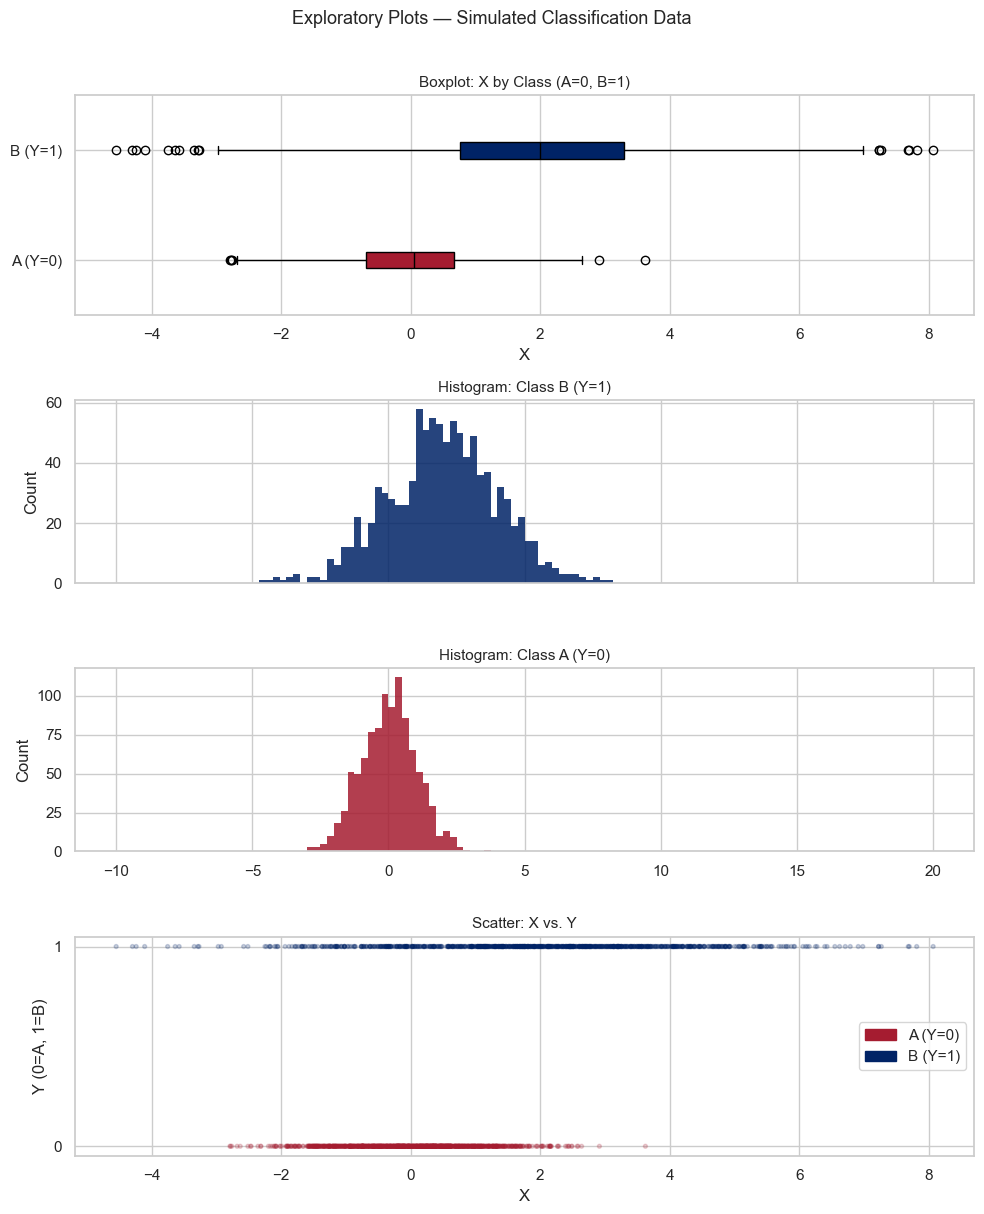

In [7]:
x_A_full = df['X'][df['Y'] == 0].values
x_B_full = df['X'][df['Y'] == 1].values

breaks = np.arange(-10, 20.25, 0.25)

fig, axes = plt.subplots(4, 1, figsize=(10, 12),
                          gridspec_kw={'height_ratios': [1.2, 1, 1, 1.2]})

# --- Panel 1: Horizontal Boxplot --- mirrors R: boxplot(x~y, horizontal=T)
bp = axes[0].boxplot([x_A_full, x_B_full],
                      vert=False,
                      patch_artist=True,
                      tick_labels=['A (Y=0)', 'B (Y=1)'])
bp['boxes'][0].set_facecolor(CRIMSON)
bp['boxes'][1].set_facecolor(ROYALBLUE)
for element in ['whiskers', 'caps', 'medians', 'fliers']:
    for patch in bp[element]:
        patch.set_color('black')
axes[0].set_title('Boxplot: X by Class (A=0, B=1)', fontsize=11)
axes[0].set_xlabel('X')

# --- Panel 2: Histogram for class B (royalblue) --- mirrors R: hist(x[y=='B'], ...)
axes[1].hist(x_B_full, bins=breaks, color=ROYALBLUE, edgecolor='none', alpha=0.85)
axes[1].set_title('Histogram: Class B (Y=1)', fontsize=11)
axes[1].set_ylabel('Count')
axes[1].set_xticklabels([])   # mirrors R: xaxt='n'

# --- Panel 3: Histogram for class A (crimson) --- mirrors R: hist(x[y=='A'], ...)
axes[2].hist(x_A_full, bins=breaks, color=CRIMSON, edgecolor='none', alpha=0.85)
axes[2].set_title('Histogram: Class A (Y=0)', fontsize=11)
axes[2].set_ylabel('Count')

# --- Panel 4: Scatter X vs. Y --- mirrors R: plot(x, ifelse(y=='A',0,1), col=...)
colors_scatter = [CRIMSON if yi == 0 else ROYALBLUE for yi in df['Y']]
axes[3].scatter(df['X'], df['Y'], c=colors_scatter, alpha=0.2, s=8)
axes[3].set_xlabel('X')
axes[3].set_ylabel('Y (0=A, 1=B)')
axes[3].set_title('Scatter: X vs. Y', fontsize=11)
axes[3].set_yticks([0, 1])
patch_A = mpatches.Patch(color=CRIMSON,   label='A (Y=0)')
patch_B = mpatches.Patch(color=ROYALBLUE, label='B (Y=1)')
axes[3].legend(handles=[patch_A, patch_B], loc='center right')

plt.suptitle('Exploratory Plots — Simulated Classification Data', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

# 1. Logistic Regression

Mirrors R: `glm(Y ~ X, data=df.train, family=binomial)`

## Fit the Model

In [8]:
# Feature matrix and labels
X_train = df_train[['X']]
y_train = df_train['Y']
X_test  = df_test[['X']]
y_test  = df_test['Y']

# Fit logistic regression — mirrors R: glm(Y~X, family=binomial)
# penalty=None removes regularization (mirrors R's unpenalized GLM)
lgr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
lgr.fit(X_train, y_train)

print('Logistic Regression — Model Summary')
print(f'  Intercept : {lgr.intercept_[0]:.6f}')
print(f'  Coeff (X) : {lgr.coef_[0][0]:.6f}')
print()
print('  Note: penalty=None mirrors R glm(family=binomial) — no regularization.')

Logistic Regression — Model Summary
  Intercept : -0.738101
  Coeff (X) : 0.816542

  Note: penalty=None mirrors R glm(family=binomial) — no regularization.


/Users/otrevizo/.venvs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Predict

Mirrors R:
```r
glm.probs <- predict(glm.fit, newdata=df.test, type='response')
glm.pred  <- rep(0, dim(df.test)[1])
glm.pred[glm.probs > 0.5] <- 1
```

In [9]:
# Predicted probabilities — mirrors R: predict(glm.fit, type='response')
lgr_probs = lgr.predict_proba(X_test)[:, 1]   # P(Y=1)

# Apply 0.5 threshold — mirrors R: glm.pred[glm.probs > 0.5] <- 1
lgr_pred = (lgr_probs > 0.5).astype(int)

print(f'Predictions shape : {lgr_pred.shape}')
print(f'Predicted class 0 : {(lgr_pred == 0).sum()}')
print(f'Predicted class 1 : {(lgr_pred == 1).sum()}')

Predictions shape : (667,)
Predicted class 0 : 362
Predicted class 1 : 305


## Confusion Matrix

Mirrors R:
```r
table(glm.pred, df.test$Y)
mean(glm.pred == df.test$Y)
```

Confusion Matrix — Logistic Regression
  (rows=actual, cols=predicted)
[[270  60]
 [ 92 245]]

Accuracy: 0.7721   — mirrors R: mean(glm.pred == df.test$Y)


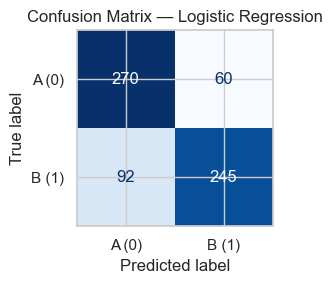

In [10]:
# Confusion matrix — mirrors R: table(glm.pred, df.test$Y)
cm_lgr = confusion_matrix(y_test, lgr_pred)

print('Confusion Matrix — Logistic Regression')
print(f'  (rows=actual, cols=predicted)')
print(cm_lgr)
print()
print(f'Accuracy: {(lgr_pred == y_test).mean():.4f}   — mirrors R: mean(glm.pred == df.test$Y)')

# Visual confusion matrix — mirrors caret::confusionMatrix display
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm_lgr, display_labels=['A (0)', 'B (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

## Prediction Metrics

Mirrors R: `lgr.metrics <- prediction.metrics(df.test$Y, lgr.pred); print.the.metrics(lgr.metrics)`

In [11]:
# Custom prediction metrics — mirrors R prediction.metrics() + print.the.metrics()
lgr_metrics = PredictionMetrics(y_test.values, lgr_pred)
lgr_metrics.print_metrics()

 OBS =    667   ..................number of observations
 ACC =   0.7721 ..................Accuracy
 TPR =   0.7270 ..................True Positive Rate (Sensitivity)
 TNR =   0.8182 ..................True Negative Rate (Specificity)
 PPV =   0.8033 ..................Positive Predictive Value (Precision)
 NPV =   0.7459 ..................Negative Predictive Value
 FDR =   0.1967 ..................False Discovery Rate
 FPR =   0.1818 ..................False Positive Rate
 TP  =    245   ..................True Positives
 TN  =    270   ..................True Negatives
 FP  =     60   ..................False Positives
 FN  =     92   ..................False Negatives
 P   =    337   ..................Positives (truth)
 N   =    330   ..................Negatives (truth)


## Classification Report

Mirrors R: `caret::confusionMatrix()` — adds precision, recall, F1 per class.

In [12]:
# Classification report — mirrors caret::confusionMatrix
print('Classification Report — Logistic Regression')
print(classification_report(y_test, lgr_pred, target_names=['A (0)', 'B (1)']))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

       A (0)       0.75      0.82      0.78       330
       B (1)       0.80      0.73      0.76       337

    accuracy                           0.77       667
   macro avg       0.77      0.77      0.77       667
weighted avg       0.77      0.77      0.77       667



## ROC Curve

Mirrors R: `pROC::roc() + plot.roc()` with `print.auc=TRUE, auc.polygon=TRUE`

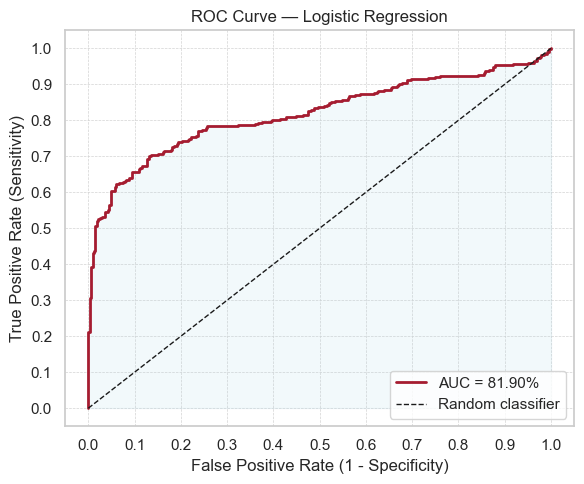

AUC (Logistic Regression): 81.90%


In [13]:
# ROC curve — mirrors R: pROC::roc(df.test$Y, p1)
fpr_lgr, tpr_lgr, _ = roc_curve(y_test, lgr_probs)
auc_lgr = auc(fpr_lgr, tpr_lgr)

plot_roc(fpr_lgr, tpr_lgr, auc_lgr,
         title='ROC Curve — Logistic Regression',
         color=CRIMSON)

print(f'AUC (Logistic Regression): {auc_lgr * 100:.2f}%')

---

# 2. Linear Discriminant Analysis (LDA)

Mirrors R: `lda(Y ~ X, data=df.train)` from `library(MASS)`

LDA assumes the class-conditional distributions share the same covariance matrix
(homoscedastic). It finds a linear decision boundary.

## Fit the Model

In [14]:
# Fit LDA — mirrors R: lda(Y~X, data=df.train)
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

print('LDA — Model Summary')
print(f'  Classes       : {lda.classes_}')
print(f'  Class priors  : {lda.priors_}')
print(f'  Group means   : {lda.means_}')
print(f'  Coefficients  : {lda.coef_[0]}')
print()
print('  Note: mirrors R lda() output — priors, group means, coefficients of linear discriminants.')

LDA — Model Summary
  Classes       : [0 1]
  Class priors  : [0.50262566 0.49737434]
  Group means   : [[0.02171278]
 [1.9792032 ]]
  Coefficients  : [0.76171168]

  Note: mirrors R lda() output — priors, group means, coefficients of linear discriminants.


## Predict

Mirrors R:
```r
lda.pred  <- predict(lda.fit, df.test)
lda.class <- lda.pred$class
```

In [15]:
# Predict — mirrors R: lda.pred <- predict(lda.fit, df.test)
lda_pred       = lda.predict(X_test)              # class labels — mirrors lda.pred$class
lda_probs      = lda.predict_proba(X_test)[:, 1]  # P(Y=1) — mirrors lda.pred$posterior

print(f'Predicted class 0 : {(lda_pred == 0).sum()}')
print(f'Predicted class 1 : {(lda_pred == 1).sum()}')

Predicted class 0 : 373
Predicted class 1 : 294


## Confusion Matrix

Confusion Matrix — LDA
[[276  54]
 [ 97 240]]
Accuracy: 0.7736


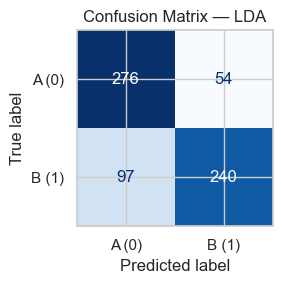

In [16]:
cm_lda = confusion_matrix(y_test, lda_pred)

print('Confusion Matrix — LDA')
print(cm_lda)
print(f'Accuracy: {(lda_pred == y_test).mean():.4f}')

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm_lda, display_labels=['A (0)', 'B (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — LDA')
plt.tight_layout()
plt.show()

## Prediction Metrics

In [17]:
lda_metrics = PredictionMetrics(y_test.values, lda_pred)
lda_metrics.print_metrics()

 OBS =    667   ..................number of observations
 ACC =   0.7736 ..................Accuracy
 TPR =   0.7122 ..................True Positive Rate (Sensitivity)
 TNR =   0.8364 ..................True Negative Rate (Specificity)
 PPV =   0.8163 ..................Positive Predictive Value (Precision)
 NPV =   0.7399 ..................Negative Predictive Value
 FDR =   0.1837 ..................False Discovery Rate
 FPR =   0.1636 ..................False Positive Rate
 TP  =    240   ..................True Positives
 TN  =    276   ..................True Negatives
 FP  =     54   ..................False Positives
 FN  =     97   ..................False Negatives
 P   =    337   ..................Positives (truth)
 N   =    330   ..................Negatives (truth)


## Classification Report

In [18]:
print('Classification Report — LDA')
print(classification_report(y_test, lda_pred, target_names=['A (0)', 'B (1)']))

Classification Report — LDA
              precision    recall  f1-score   support

       A (0)       0.74      0.84      0.79       330
       B (1)       0.82      0.71      0.76       337

    accuracy                           0.77       667
   macro avg       0.78      0.77      0.77       667
weighted avg       0.78      0.77      0.77       667



## ROC Curve

Mirrors R: `roc(df.test$Y, p1$x)` — using LDA discriminant scores (posterior probabilities).

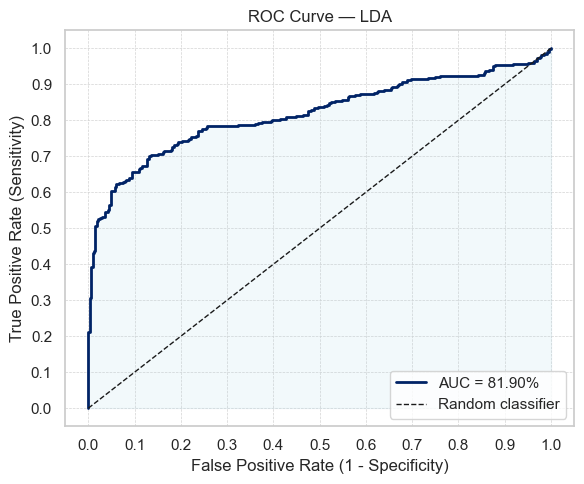

AUC (LDA): 81.90%


In [19]:
fpr_lda, tpr_lda, _ = roc_curve(y_test, lda_probs)
auc_lda = auc(fpr_lda, tpr_lda)

plot_roc(fpr_lda, tpr_lda, auc_lda,
         title='ROC Curve — LDA',
         color=ROYALBLUE)

print(f'AUC (LDA): {auc_lda * 100:.2f}%')

---

# 3. Quadratic Discriminant Analysis (QDA)

Mirrors R: `qda(Y ~ X, data=df.train)` from `library(MASS)`

QDA relaxes LDA's equal-covariance assumption — each class gets its own covariance
matrix, producing a **quadratic** (curved) decision boundary. More flexible but
requires more data to estimate parameters reliably.

## Fit the Model

In [20]:
# Fit QDA — mirrors R: qda(Y~X, data=df.train)
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

print('QDA — Model Summary')
print(f'  Classes      : {qda.classes_}')
print(f'  Class priors : {qda.priors_}')
print(f'  Group means  : {qda.means_}')

QDA — Model Summary
  Classes      : [0 1]
  Class priors : [0.50262566 0.49737434]
  Group means  : [[0.02171278]
 [1.9792032 ]]


## Predict

Mirrors R:
```r
qda.pred  <- predict(qda.fit, df.test)
qda.class <- qda.pred$class
```

In [21]:
# Predict — mirrors R: qda.pred <- predict(qda.fit, df.test)
qda_pred  = qda.predict(X_test)               # class labels — mirrors qda.pred$class
qda_probs = qda.predict_proba(X_test)[:, 1]   # P(Y=1) — mirrors qda.pred$posterior[,2]

print(f'Predicted class 0 : {(qda_pred == 0).sum()}')
print(f'Predicted class 1 : {(qda_pred == 1).sum()}')

Predicted class 0 : 412
Predicted class 1 : 255


## Confusion Matrix

Confusion Matrix — QDA
[[298  32]
 [114 223]]
Accuracy: 0.7811


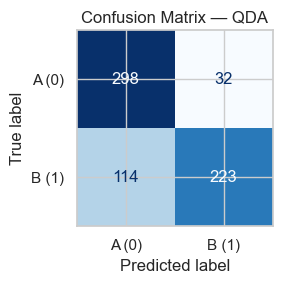

In [22]:
cm_qda = confusion_matrix(y_test, qda_pred)

print('Confusion Matrix — QDA')
print(cm_qda)
print(f'Accuracy: {(qda_pred == y_test).mean():.4f}')

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm_qda, display_labels=['A (0)', 'B (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — QDA')
plt.tight_layout()
plt.show()

## Prediction Metrics

In [23]:
qda_metrics = PredictionMetrics(y_test.values, qda_pred)
qda_metrics.print_metrics()

 OBS =    667   ..................number of observations
 ACC =   0.7811 ..................Accuracy
 TPR =   0.6617 ..................True Positive Rate (Sensitivity)
 TNR =   0.9030 ..................True Negative Rate (Specificity)
 PPV =   0.8745 ..................Positive Predictive Value (Precision)
 NPV =   0.7233 ..................Negative Predictive Value
 FDR =   0.1255 ..................False Discovery Rate
 FPR =   0.0970 ..................False Positive Rate
 TP  =    223   ..................True Positives
 TN  =    298   ..................True Negatives
 FP  =     32   ..................False Positives
 FN  =    114   ..................False Negatives
 P   =    337   ..................Positives (truth)
 N   =    330   ..................Negatives (truth)


## Classification Report

In [24]:
print('Classification Report — QDA')
print(classification_report(y_test, qda_pred, target_names=['A (0)', 'B (1)']))

Classification Report — QDA
              precision    recall  f1-score   support

       A (0)       0.72      0.90      0.80       330
       B (1)       0.87      0.66      0.75       337

    accuracy                           0.78       667
   macro avg       0.80      0.78      0.78       667
weighted avg       0.80      0.78      0.78       667



## ROC Curve

Mirrors R: `roc(df.test$Y, p1$posterior[,1])` — using QDA posterior probabilities.

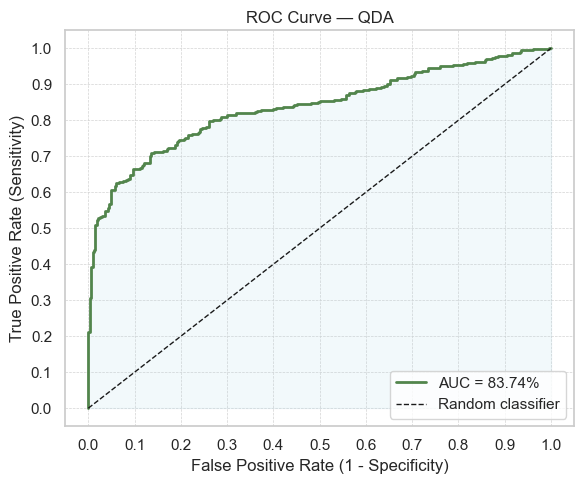

AUC (QDA): 83.74%


In [25]:
fpr_qda, tpr_qda, _ = roc_curve(y_test, qda_probs)
auc_qda = auc(fpr_qda, tpr_qda)

plot_roc(fpr_qda, tpr_qda, auc_qda,
         title='ROC Curve — QDA',
         color=IVY)

print(f'AUC (QDA): {auc_qda * 100:.2f}%')

---

# Summary and Conclusions

## Model Comparison

In [26]:
# Comparison table across all three classifiers
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', **lgr_metrics.to_dict(), 'AUC': auc_lgr},
    {'Model': 'LDA',                 **lda_metrics.to_dict(), 'AUC': auc_lda},
    {'Model': 'QDA',                 **qda_metrics.to_dict(), 'AUC': auc_qda},
])

# Show key metrics
key_cols = ['Model', 'OBS', 'ACC', 'TPR', 'TNR', 'PPV', 'FPR', 'AUC']
print('Model Comparison — Key Metrics')
print(comparison[key_cols].to_string(index=False, float_format='{:.4f}'.format))

Model Comparison — Key Metrics
              Model  OBS    ACC    TPR    TNR    PPV    FPR    AUC
Logistic Regression  667 0.7721 0.7270 0.8182 0.8033 0.1818 0.8190
                LDA  667 0.7736 0.7122 0.8364 0.8163 0.1636 0.8190
                QDA  667 0.7811 0.6617 0.9030 0.8745 0.0970 0.8374


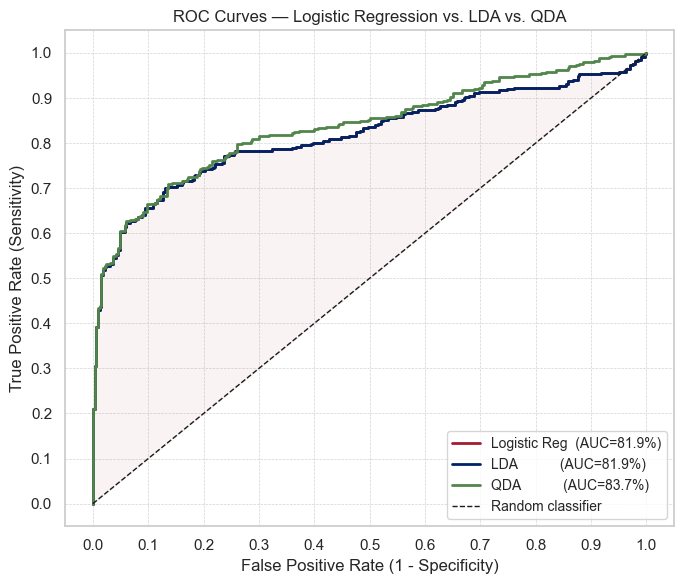

In [27]:
# Overlay all three ROC curves for direct comparison
fig, ax = plt.subplots(figsize=(7, 6))

for (fpr, tpr, roc_auc, label, color) in [
    (fpr_lgr, tpr_lgr, auc_lgr, f'Logistic Reg  (AUC={auc_lgr*100:.1f}%)', CRIMSON),
    (fpr_lda, tpr_lda, auc_lda, f'LDA           (AUC={auc_lda*100:.1f}%)', ROYALBLUE),
    (fpr_qda, tpr_qda, auc_qda, f'QDA           (AUC={auc_qda*100:.1f}%)', IVY),
]:
    ax.plot(fpr, tpr, linewidth=2, label=label, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.fill_between(fpr_lgr, fpr_lgr, tpr_lgr, alpha=0.05, color=CRIMSON)

ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.grid(True, linestyle='--', linewidth=0.5, color='lightgrey')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — Logistic Regression vs. LDA vs. QDA')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Logistic Regression** and **LDA** tend to produce very similar results on linearly
   separable or near-linearly-separable data. LDA makes a stronger distributional
   assumption (Gaussian with equal covariance) but is often just as accurate.

2. **QDA** relaxes the equal-covariance assumption, fitting a quadratic boundary.
   Here, because class B has higher variance (sd=2 vs sd=1), QDA can exploit
   this asymmetry — observe its ROC curve relative to LDA.

3. The **PredictionMetrics class** provides a clean Python equivalent to the
   custom R `prediction.metrics()` function — reusable across all classification notebooks.

4. **Harvard color palette** (crimson, royalblue) preserved as named constants
   for visual consistency with the original R analysis.

## R → Python Mapping

| R | Python |
|---|--------|
| `glm(Y~X, family=binomial)` | `sklearn.LogisticRegression(penalty=None)` |
| `predict(glm.fit, type='response')` | `lgr.predict_proba(X_test)[:, 1]` |
| `MASS::lda(Y~X, data=train)` | `sklearn.LinearDiscriminantAnalysis()` |
| `lda.pred$class` | `lda.predict(X_test)` |
| `lda.pred$posterior` | `lda.predict_proba(X_test)` |
| `MASS::qda(Y~X, data=train)` | `sklearn.QuadraticDiscriminantAnalysis()` |
| `qda.pred$posterior[,1]` | `qda.predict_proba(X_test)[:, 1]` |
| `table(pred, truth)` | `sklearn.metrics.confusion_matrix()` |
| `mean(pred == truth)` | `(pred == truth).mean()` |
| `caret::confusionMatrix()` | `sklearn.metrics.classification_report()` |
| `pROC::roc() + plot.roc()` | `sklearn.metrics.roc_curve()` + `matplotlib` |
| `prediction.metrics()` (custom R fn) | `PredictionMetrics` class |
| `print.the.metrics()` (custom R fn) | `PredictionMetrics.print_metrics()` |
| `rnorm(N, mean=mu, sd=sd)` | `np.random.default_rng(seed).normal(loc, scale, size)` |
| `set.seed()` | `np.random.default_rng(seed=)` |
| R color palette (crimson, royalblue) | Named hex constants (CRIMSON, ROYALBLUE) |

## References

1. Harvard "Elements of Statistical Learning" (2021), Dr. Sivachenko and Dr. Farutin.
2. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com